In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/bda/bda_머신러닝스터디/train.csv')

In [ ]:
df.columns #변수확인

Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')

In [ ]:
#변수삭제
df.drop(labels=['id','name','neighbourhood','thumbnail_url','instant_bookable'],axis=1,inplace=True)

In [ ]:
#삭제된 변수 확인
df.columns

Index(['log_price', 'property_type', 'room_type', 'amenities', 'accommodates',
       'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city',
       'description', 'first_review', 'host_has_profile_pic',
       'host_identity_verified', 'host_response_rate', 'host_since',
       'last_review', 'latitude', 'longitude', 'number_of_reviews',
       'review_scores_rating', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')

In [ ]:
#변수 삭제 2
df.drop(['description','first_review','host_has_profile_pic','host_identity_verified','host_response_rate','host_since','last_review','zipcode'], axis=1, inplace=True)

In [ ]:
#남은 변수 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   log_price             74111 non-null  float64
 1   property_type         74111 non-null  object 
 2   room_type             74111 non-null  object 
 3   amenities             74111 non-null  object 
 4   accommodates          74111 non-null  int64  
 5   bathrooms             73911 non-null  float64
 6   bed_type              74111 non-null  object 
 7   cancellation_policy   74111 non-null  object 
 8   cleaning_fee          74111 non-null  bool   
 9   city                  74111 non-null  object 
 10  latitude              74111 non-null  float64
 11  longitude             74111 non-null  float64
 12  number_of_reviews     74111 non-null  int64  
 13  review_scores_rating  57389 non-null  float64
 14  bedrooms              74020 non-null  float64
 15  beds               

In [ ]:
#결측값 확인
df.isnull().sum()

,0
log_price,0
property_type,0
room_type,0
amenities,0
accommodates,0
bathrooms,200
bed_type,0
cancellation_policy,0
cleaning_fee,0
city,0


In [ ]:
#결측치 제거
df.dropna(axis=0, how='any', inplace= True)
df= df.reset_index(drop=True)

In [ ]:
df.isnull().sum()

,0
log_price,0
property_type,0
room_type,0
amenities,0
accommodates,0
bathrooms,0
bed_type,0
cancellation_policy,0
cleaning_fee,0
city,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57129 entries, 0 to 57128
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   log_price             57129 non-null  float64
 1   property_type         57129 non-null  object 
 2   room_type             57129 non-null  object 
 3   amenities             57129 non-null  object 
 4   accommodates          57129 non-null  int64  
 5   bathrooms             57129 non-null  float64
 6   bed_type              57129 non-null  object 
 7   cancellation_policy   57129 non-null  object 
 8   cleaning_fee          57129 non-null  bool   
 9   city                  57129 non-null  object 
 10  latitude              57129 non-null  float64
 11  longitude             57129 non-null  float64
 12  number_of_reviews     57129 non-null  int64  
 13  review_scores_rating  57129 non-null  float64
 14  bedrooms              57129 non-null  float64
 15  beds               

In [ ]:
#범주 확인
df['property_type'].value_counts()

,count
property_type,
Apartment,37567
House,12989
Condominium,1997
Townhouse,1292
Loft,1010
Other,418
Guesthouse,409
Bed & Breakfast,353
Bungalow,307


In [ ]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,32900
Private room,22796
Shared room,1433


In [ ]:
df['bed_type'].value_counts()

,count
bed_type,
Real Bed,55537
Futon,600
Pull-out Sofa,492
Airbed,342
Couch,158


In [ ]:
df['city'].value_counts()

,count
city,
NYC,24887
LA,17114
SF,5029
DC,4084
Chicago,3204
Boston,2811


In [ ]:
df['cancellation_policy'].value_counts()

,count
cancellation_policy,
strict,27681
moderate,16432
flexible,12928
super_strict_30,78
super_strict_60,10


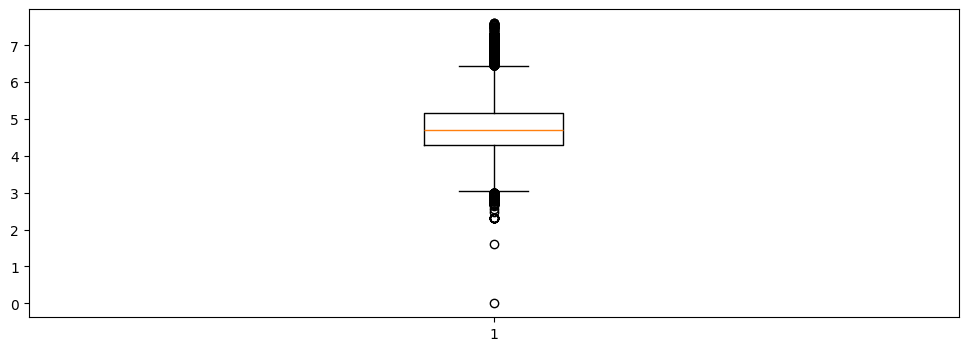

In [ ]:
#이상치 확인 - log_price
plt.figure(figsize=(12,4))
plt.boxplot(df['log_price'])
plt.show()

In [ ]:
Q1=df['log_price'].quantile(0.25)
Q3=df['log_price'].quantile(0.75)
IQR=Q3-Q1

lb = Q1-1.5*IQR
ub=Q3+1.5*IQR

In [ ]:
outliers_idx = []

outliers_idx.extend(df[(df['log_price'] < lb) | (df['log_price'] > ub)].index)
len(outliers_idx)

935

In [ ]:
df.drop(outliers_idx, inplace=True)

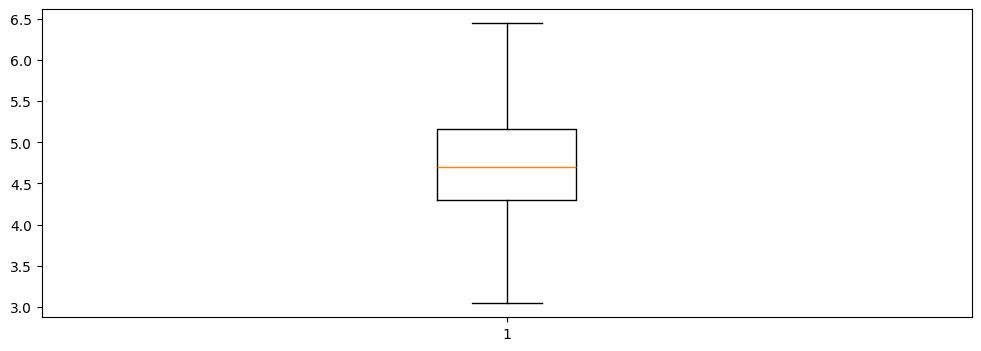

In [ ]:
#이상치 삭제 확인 - log_price
plt.figure(figsize=(12,4))
plt.boxplot(df['log_price'])
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56194 entries, 0 to 57128
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   log_price             56194 non-null  float64
 1   property_type         56194 non-null  object 
 2   room_type             56194 non-null  object 
 3   amenities             56194 non-null  object 
 4   accommodates          56194 non-null  int64  
 5   bathrooms             56194 non-null  float64
 6   bed_type              56194 non-null  object 
 7   cancellation_policy   56194 non-null  object 
 8   cleaning_fee          56194 non-null  bool   
 9   city                  56194 non-null  object 
 10  latitude              56194 non-null  float64
 11  longitude             56194 non-null  float64
 12  number_of_reviews     56194 non-null  int64  
 13  review_scores_rating  56194 non-null  float64
 14  bedrooms              56194 non-null  float64
 15  beds                  56

In [ ]:
#편의시설
df['amenities']

,amenities
0,"{""Wireless Internet"",""Air conditioning"",Kitche..."
1,"{""Wireless Internet"",""Air conditioning"",Kitche..."
2,"{TV,""Cable TV"",""Wireless Internet"",""Air condit..."
3,"{TV,Internet,""Wireless Internet"",""Air conditio..."
4,"{TV,""Wireless Internet"",Heating,""Smoke detecto..."
...,...
57124,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A..."
57125,"{TV,Internet,""Wireless Internet"",""Air conditio..."
57126,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki..."
57127,"{TV,Internet,""Wireless Internet"",""Air conditio..."


In [ ]:
amenities = df['amenities'].values.tolist()
cleaned_amenities=[s.replace("'","").replace("{","").replace("}","").replace('"',"") for s in amenities]

In [ ]:
#문자 정리 확인
cleaned_amenities[:3]

['Wireless Internet,Air conditioning,Kitchen,Heating,Family/kid friendly,Essentials,Hair dryer,Iron,translation missing: en.hosting_amenity_50',
 'Wireless Internet,Air conditioning,Kitchen,Heating,Family/kid friendly,Washer,Dryer,Smoke detector,Fire extinguisher,Essentials,Shampoo,Hangers,Hair dryer,Iron,translation missing: en.hosting_amenity_50',
 'TV,Cable TV,Wireless Internet,Air conditioning,Kitchen,Breakfast,Buzzer/wireless intercom,Heating,Family/kid friendly,Smoke detector,Carbon monoxide detector,Fire extinguisher,Essentials,Shampoo,Hangers,Hair dryer,Iron,Laptop friendly workspace,translation missing: en.hosting_amenity_50']

In [ ]:
len(cleaned_amenities)

56194

In [ ]:
# 편의시설 종류 별 총 개수
from collections import Counter

combined_data = ','.join(cleaned_amenities).split(',')

element_counts = Counter(combined_data)

print(element_counts)


Counter({'Wireless Internet': 54829, 'Heating': 52150, 'Kitchen': 51539, 'Essentials': 49704, 'Smoke detector': 48039, 'Air conditioning': 42600, 'TV': 40381, 'Shampoo': 39592, 'Hangers': 39114, 'Carbon monoxide detector': 37601, 'Internet': 36667, 'Hair dryer': 35246, 'Laptop friendly workspace': 34650, 'Iron': 33921, 'Washer': 32365, 'Dryer': 32082, 'Family/kid friendly': 29124, 'Fire extinguisher': 24564, 'First aid kit': 22168, 'translation missing: en.hosting_amenity_50': 20737, 'Cable TV': 19523, 'Free parking on premises': 18126, '24-hour check-in': 16664, 'translation missing: en.hosting_amenity_49': 16447, 'Buzzer/wireless intercom': 13886, 'Lock on bedroom door': 13311, 'Self Check-In': 10087, 'Safety card': 9199, 'Pets live on this property': 8074, 'Pets allowed': 7714, 'Elevator': 7659, 'Indoor fireplace': 6809, 'Breakfast': 6253, 'Private entrance': 5851, 'Lockbox': 5362, 'Gym': 5067, 'Elevator in building': 4589, 'Dog(s)': 4464, 'Hot tub': 4443, 'Pool': 4292, 'Refrigerato

In [ ]:
# 각 데이터별 편의시설 개수
amenities_count = []

excluded_values=['translation missing: en.hosting_amenity_50','translation missing: en.hosting_amenity_49']

for data in cleaned_amenities:
    elements = data.split(',')
    count= sum(1 for element in elements if element not in excluded_values)
    amenities_count.append(count)

print(amenities_count[:5], '...', amenities_count[-5:])

[8, 14, 18, 12, 10] ... [26, 13, 15, 31, 18]


In [ ]:
len(amenities_count)

56194

In [ ]:
df['amenities_count'] = amenities_count

In [ ]:
df.head()

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds,amenities_count
0,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,40.696524,-73.991617,2,100.0,1.0,1.0,8
1,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,40.766115,-73.989040,6,93.0,3.0,3.0,14
2,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,40.808110,-73.943756,10,92.0,1.0,3.0,18
3,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,38.925627,-77.034596,4,40.0,0.0,1.0,12
4,4.442651,Apartment,Private room,"{TV,""Wireless Internet"",Heating,""Smoke detecto...",2,1.0,Real Bed,strict,True,SF,37.753164,-122.429526,3,100.0,1.0,1.0,10


In [ ]:
df = df[['log_price','property_type','room_type','bathrooms','bedrooms','beds','bed_type','amenities','amenities_count','accommodates', 'cancellation_policy','cleaning_fee','city','latitude','longitude','number_of_reviews','review_scores_rating']]

In [ ]:
df['property_type'].value_counts()

,count
property_type,
Apartment,37294
House,12514
Condominium,1953
Townhouse,1259
Loft,976
Other,410
Guesthouse,408
Bed & Breakfast,350
Bungalow,305


In [ ]:
#변수 지우기
values_to_remove=['Boat','Boutique hotel','Camper/RV','Castle','Cave','Earth House','Hut','Island','Other','Serviced apartment','Tent','Train','Tipi','Treehouse','Timeshare','Yurt']
df = df[~df['property_type'].isin(values_to_remove)]

In [ ]:
#변수 합치기
df['property_type']=df['property_type'].replace({'Dorm':'Guesthouse'})

In [ ]:
df['property_type'].value_counts()

,count
property_type,
Apartment,37294
House,12514
Condominium,1953
Townhouse,1259
Loft,976
Guesthouse,503
Bed & Breakfast,350
Bungalow,305
Villa,104


In [ ]:
#변수 합치기
df['property_type'] = df['property_type'].replace({'Hostel':'Guesthouse','In-law':'Guest suite','Townhouse':'House','Villa':'Vacation home','Chalet':'Vacation home','Cabin':'Vacation home'})

In [ ]:
df['property_type'].value_counts()

,count
property_type,
Apartment,37294
House,13773
Condominium,1953
Loft,976
Guesthouse,537
Bed & Breakfast,350
Bungalow,305
Vacation home,178
Guest suite,162


In [ ]:
df['city'].value_counts()

,count
city,
NYC,24465
LA,16418
SF,4793
DC,3982
Chicago,3127
Boston,2743


In [ ]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,31726
Private room,22508
Shared room,1294


In [ ]:
df['bed_type'].value_counts()

,count
bed_type,
Real Bed,53989
Futon,582
Pull-out Sofa,484
Airbed,325
Couch,148


In [ ]:
df['cancellation_policy'].value_counts()

,count
cancellation_policy,
strict,26714
moderate,16108
flexible,12623
super_strict_30,78
super_strict_60,5


In [ ]:
df.to_excel('/content/drive/MyDrive/bda/bda_머신러닝스터디/airbnb_preprocessed.xlsx', index=False)

Exception ignored in: <function ZipFile.__del__ at 0x7940c3101300>
Traceback (most recent call last):
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1966, in __del__
    self.close()
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1983, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file
